In [58]:
import pickle
import streamlit as st

In [6]:
import os
os.chdir("C:/Users/Simon/Documents/UZH/DataAnalysiswithPython/SimonteBiesebeekPlayground/SimonteBiesebeekPlayground/FinalProject")
print(os.getcwd())

C:\Users\Simon\Documents\UZH\DataAnalysiswithPython\SimonteBiesebeekPlayground\SimonteBiesebeekPlayground\FinalProject


In [7]:
import os
import pandas as pd

csv_files = [f for f in os.listdir("PremierData") if f.endswith(".csv")]
dataframes = {f: pd.read_csv(os.path.join("PremierData", f)) for f in csv_files}

In [8]:
files = os.listdir("PremierData")
print(files)

['PremierData2021.csv', 'PremierData2122.csv', 'PremierData2223.csv', 'PremierData2324.csv', 'PremierData2425.csv']


In [27]:
from pathlib import Path

data_folder = Path("PremierData")

# Create one combined DataFrame, adding a Season column automatically
premier_data = pd.concat(
    [
        pd.read_csv(f).assign(
            Season=f.stem.replace("PremierData", "")  # e.g. "Data2122" → "2122"
        )
        for f in data_folder.glob("*.csv")
    ],
    ignore_index=True
)
premier_data.to_csv("MergedPremierLeagueData.csv", index=False)
merged_premier = pd.read_csv("MergedPremierLeagueData.csv")
merged_premier['Date'] = pd.to_datetime(merged_premier['Date'], dayfirst=True, errors='coerce')
merged_premier['Time'] = pd.to_datetime(merged_premier['Time'], format='%H:%M', errors='coerce').dt.time

# 2. Sort chronologically
merged_premier = merged_premier.sort_values(by=['Date', 'Time']).reset_index(drop=True)

# 3. Reformat them for display (DD/MM/YYYY and HH:MM)
merged_premier['Date'] = merged_premier['Date'].dt.strftime('%d/%m/%Y')
merged_premier['Time'] = merged_premier['Time'].apply(lambda t: t.strftime('%H:%M') if pd.notnull(t) else '')

# 4. Preview
merged_premier[['Date', 'Time']].head()
merged_premier.head()


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,1XBCH,1XBCD,1XBCA,BFECH,BFECD,BFECA,BFEC>2.5,BFEC<2.5,BFECAHH,BFECAHA
0,E0,12/09/2020,12:30,Fulham,Arsenal,0,3,A,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,12/09/2020,15:00,Crystal Palace,Southampton,1,0,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,12/09/2020,17:30,Liverpool,Leeds,4,3,H,3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,12/09/2020,20:00,West Ham,Newcastle,0,2,A,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,13/09/2020,14:00,West Brom,Leicester,0,3,A,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
print(merged_premier.shape)

(1900, 133)


In [28]:
merged_premier['Winner'] = merged_premier.apply(
    lambda row: row['HomeTeam'] if row['FTR'] == 'H' 
                else (row['AwayTeam'] if row['FTR'] == 'A' else 'Draw'),
    axis=1
)
print(merged_premier.head())

  Div        Date   Time        HomeTeam     AwayTeam  FTHG  FTAG FTR  HTHG  \
0  E0  12/09/2020  12:30          Fulham      Arsenal     0     3   A     0   
1  E0  12/09/2020  15:00  Crystal Palace  Southampton     1     0   H     1   
2  E0  12/09/2020  17:30       Liverpool        Leeds     4     3   H     3   
3  E0  12/09/2020  20:00        West Ham    Newcastle     0     2   A     0   
4  E0  13/09/2020  14:00       West Brom    Leicester     0     3   A     0   

   HTAG  ... 1XBCD 1XBCA  BFECH  BFECD  BFECA  BFEC>2.5  BFEC<2.5  BFECAHH  \
0     1  ...   NaN   NaN    NaN    NaN    NaN       NaN       NaN      NaN   
1     0  ...   NaN   NaN    NaN    NaN    NaN       NaN       NaN      NaN   
2     2  ...   NaN   NaN    NaN    NaN    NaN       NaN       NaN      NaN   
3     0  ...   NaN   NaN    NaN    NaN    NaN       NaN       NaN      NaN   
4     0  ...   NaN   NaN    NaN    NaN    NaN       NaN       NaN      NaN   

   BFECAHA          Winner  
0      NaN         Arsenal 

In [29]:
merged_premier['HomeTeam'].unique()

array(['Fulham', 'Crystal Palace', 'Liverpool', 'West Ham', 'West Brom',
       'Tottenham', 'Sheffield United', 'Brighton', 'Everton', 'Leeds',
       'Man United', 'Arsenal', 'Southampton', 'Newcastle', 'Chelsea',
       'Leicester', 'Aston Villa', 'Wolves', 'Burnley', 'Man City',
       'Brentford', 'Watford', 'Norwich', 'Bournemouth', "Nott'm Forest",
       'Luton', 'Ipswich'], dtype=object)

In [30]:
merged_premier["GoalDifference"] = merged_premier["FTHG"] - merged_premier["FTAG"]
print(merged_premier["GoalDifference"])

0      -3
1       1
2       1
3      -2
4      -3
       ..
1895   -1
1896   -1
1897   -1
1898   -3
1899    0
Name: GoalDifference, Length: 1900, dtype: int64


In [31]:
import numpy as np

# Assign points based on match result (FTR = 'H', 'A', 'D')
merged_premier["HomePoints"] = np.select(
    [
        merged_premier["FTR"] == "H",  # Home win
        merged_premier["FTR"] == "D",  # Draw
        merged_premier["FTR"] == "A"   # Away win
    ],
    [3, 1, 0]
)

merged_premier["AwayPoints"] = np.select(
    [
        merged_premier["FTR"] == "A",  # Away win
        merged_premier["FTR"] == "D",  # Draw
        merged_premier["FTR"] == "H"   # Home win
    ],
    [3, 1, 0]
)

print(merged_premier[["FTR", "HomePoints", "AwayPoints"]])

     FTR  HomePoints  AwayPoints
0      A           0           3
1      H           3           0
2      H           3           0
3      A           0           3
4      A           0           3
...   ..         ...         ...
1895   A           0           3
1896   A           0           3
1897   A           0           3
1898   A           0           3
1899   D           1           1

[1900 rows x 3 columns]


In [32]:
home_points = merged_premier.groupby("HomeTeam")["HomePoints"].sum().reset_index()
away_points = merged_premier.groupby("AwayTeam")["AwayPoints"].sum().reset_index()
total_points = pd.merge(home_points, away_points, left_on="HomeTeam", right_on="AwayTeam", how="outer").fillna(0)
total_points["Team"] = total_points["HomeTeam"].combine_first(total_points["AwayTeam"])
print(total_points.head())

      HomeTeam  HomePoints     AwayTeam  AwayPoints         Team
0      Arsenal         200      Arsenal         177      Arsenal
1  Aston Villa         166  Aston Villa         129  Aston Villa
2  Bournemouth          77  Bournemouth          66  Bournemouth
3    Brentford         114    Brentford          86    Brentford
4     Brighton         139     Brighton         124     Brighton


In [35]:
home_gd = merged_premier.groupby("HomeTeam")["GoalDifference"].sum().reset_index()
home_gd.columns = ["Team", "HomeGD"]

# Away teams: negate GD to reflect their perspective
away_gd = merged_premier.groupby("AwayTeam")["GoalDifference"].sum().reset_index()
away_gd["GoalDifference"] = -away_gd["GoalDifference"]
away_gd.columns = ["Team", "AwayGD"]

# Combine both
total_gd = pd.merge(home_gd, away_gd, on="Team", how="outer").fillna(0)

# Total goal difference = home + away
total_gd["TotalGD"] = total_gd["HomeGD"] + total_gd["AwayGD"]

# Sort nicely
total_gd = total_gd.sort_values(by="TotalGD", ascending=False).reset_index(drop=True)

print(total_gd)

                Team  HomeGD  AwayGD  TotalGD
0           Man City     167     108      275
1          Liverpool     136      76      212
2            Arsenal      99      72      171
3            Chelsea      64      27       91
4          Tottenham      57      14       71
5          Newcastle      61     -16       45
6        Aston Villa      48     -14       34
7         Man United      44     -11       33
8           Brighton      19      -8       11
9          Brentford      18     -14        4
10          West Ham      11     -30      -19
11            Fulham     -13     -17      -30
12    Crystal Palace       5     -36      -31
13             Luton      -9     -24      -33
14       Bournemouth      -2     -33      -35
15     Nott'm Forest      10     -46      -36
16         West Brom     -24     -17      -41
17         Leicester      -8     -35      -43
18           Watford     -29     -14      -43
19           Ipswich     -30     -16      -46
20             Leeds     -23     -

In [37]:
total_points = total_points[["Team", "HomePoints", "AwayPoints", "TotalPoints", "HomePointsPct"]]
print(total_points.sort_values("HomePointsPct", ascending=False))

                Team  HomePoints  AwayPoints  TotalPoints  HomePointsPct
20  Sheffield United          26          13           39      66.666667
14             Luton          16          10           26      61.538462
19     Nott'm Forest          82          57          139      58.992806
17         Newcastle         170         121          291      58.419244
24         West Brom          15          11           26      57.692308
21       Southampton          69          51          120      57.500000
22         Tottenham         170         127          297      57.239057
3          Brentford         114          86          200      57.000000
26            Wolves         127          98          225      56.444444
1        Aston Villa         166         129          295      56.271186
25          West Ham         143         113          256      55.859375
13         Liverpool         220         174          394      55.837563
7     Crystal Palace         133         106       

In [38]:
merged_premier['Shots_Difference'] = merged_premier['HS'] - merged_premier['AS']
print(merged_premier['Shots_Difference'])

0       -8
1       -4
2       16
3        0
4       -6
        ..
1895     3
1896     4
1897   -16
1898   -19
1899     5
Name: Shots_Difference, Length: 1900, dtype: int64


In [41]:
from sklearn.linear_model import LogisticRegression
merged_premier['HomeWin'] = (merged_premier['Winner'] == merged_premier['HomeTeam']).astype(int)
X = merged_premier[['Shots_Difference']]  # predictor
y = merged_premier['HomeWin']             # target

model = LogisticRegression()
model.fit(X, y)

print(f"Intercept: {model.intercept_[0]}")
print(f"Coefficient for Shots_Difference: {model.coef_[0][0]}")

# Predict probabilities
merged_premier['HomeWin_Prob'] = model.predict_proba(X)[:, 1]

Intercept: -0.47019273553972596
Coefficient for Shots_Difference: 0.07536591911688537


In [42]:
merged_premier['ShotsonTarget_Difference'] = merged_premier['HST'] - merged_premier['AST']
print(merged_premier['ShotsonTarget_Difference'])

0      -4
1      -2
2       3
3       1
4      -6
       ..
1895    0
1896    0
1897   -6
1898   -6
1899   -1
Name: ShotsonTarget_Difference, Length: 1900, dtype: int64


In [43]:
from sklearn.linear_model import LogisticRegression
merged_premier['HomeWin'] = (merged_premier['Winner'] == merged_premier['HomeTeam']).astype(int)
X = merged_premier[['ShotsonTarget_Difference']]  # predictor
y = merged_premier['HomeWin']             # target

model = LogisticRegression()
model.fit(X, y)

print(f"Intercept: {model.intercept_[0]}")
print(f"Coefficient for ShotsonTarget_Difference: {model.coef_[0][0]}")

# Predict probabilities
merged_premier['HomeWin_Prob'] = model.predict_proba(X)[:, 1]

Intercept: -0.652344044591553
Coefficient for ShotsonTarget_Difference: 0.37100346619420704


In [45]:
merged_premier['FTR'].value_counts()

FTR
H    821
A    646
D    433
Name: count, dtype: int64

<Axes: xlabel='Season'>

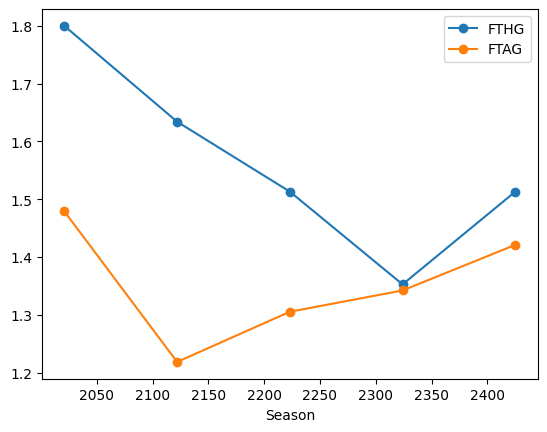

In [46]:
merged_premier.groupby('Season')[['FTHG', 'FTAG']].mean().plot(marker='o')

In [47]:
team_stats = pd.DataFrame({
    'AvgGoalsScored': merged_premier.groupby('HomeTeam')['FTHG'].mean(),
    'AvgGoalsConceded': merged_premier.groupby('HomeTeam')['FTAG'].mean(),
})
print(team_stats)

                  AvgGoalsScored  AvgGoalsConceded
HomeTeam                                          
Arsenal                 2.052632          1.010526
Aston Villa             1.821053          1.315789
Bournemouth             1.228070          1.263158
Brentford               1.657895          1.421053
Brighton                1.452632          1.252632
Burnley                 0.894737          1.666667
Chelsea                 1.757895          1.084211
Crystal Palace          1.357895          1.305263
Everton                 1.210526          1.273684
Fulham                  1.289474          1.460526
Ipswich                 0.736842          2.315789
Leeds                   1.280702          1.684211
Leicester               1.394737          1.500000
Liverpool               2.263158          0.831579
Luton                   1.473684          1.947368
Man City                2.684211          0.926316
Man United              1.684211          1.221053
Newcastle               1.86315

In [48]:
# Create conditions for when home or away team is leading at half time
merged_premier['HT_leader'] = merged_premier.apply(
    lambda x: 'Home' if x['HTHG'] > x['HTAG'] else ('Away' if x['HTHG'] < x['HTAG'] else 'Draw'),
    axis=1
)

# For each team, compute % of wins when leading at half time
# 1️⃣ Home teams
home_leads = merged_premier[merged_premier['HT_leader'] == 'Home'].groupby('HomeTeam').agg(
    games_leading=('HomeTeam', 'count'),
    wins_when_leading=('FTR', lambda x: (x == 'H').sum())
)
home_leads['home_win_pct_when_leading_HT'] = 100 * home_leads['wins_when_leading'] / home_leads['games_leading']

# 2️⃣ Away teams
away_leads = merged_premier[merged_premier['HT_leader'] == 'Away'].groupby('AwayTeam').agg(
    games_leading=('AwayTeam', 'count'),
    wins_when_leading=('FTR', lambda x: (x == 'A').sum())
)
away_leads['away_win_pct_when_leading_HT'] = 100 * away_leads['wins_when_leading'] / away_leads['games_leading']

# Combine into one dataframe per team
team_win_pct = pd.concat([home_leads['home_win_pct_when_leading_HT'], 
                          away_leads['away_win_pct_when_leading_HT']], axis=1).fillna(0)

team_win_pct['overall_win_pct_when_leading_HT'] = (
    (home_leads['wins_when_leading'].fillna(0) + away_leads['wins_when_leading'].fillna(0)) /
    (home_leads['games_leading'].fillna(0) + away_leads['games_leading'].fillna(0))
) * 100

# Sort descending for clarity
team_win_pct = team_win_pct.sort_values('overall_win_pct_when_leading_HT', ascending=False)

team_win_pct

,home_win_pct_when_leading_HT,away_win_pct_when_leading_HT,overall_win_pct_when_leading_HT
Liverpool,91.666667,85.294118,89.024390
Man City,87.096774,86.046512,86.666667
Arsenal,83.720930,83.720930,83.720930
Leicester,90.476190,71.428571,82.857143
Newcastle,79.487179,86.956522,82.258065
Man United,81.250000,78.260870,80.000000
Sheffield United,80.000000,75.000000,77.777778
Aston Villa,82.500000,70.370370,77.611940
Chelsea,72.222222,76.666667,74.242424
Tottenham,75.000000,69.696970,72.602740


In [53]:
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = 'vscode'

team_win_pct_sorted = team_win_pct.sort_values('overall_win_pct_when_leading_HT', ascending=False).reset_index()
team_names = team_win_pct_sorted['index']

win_fig_prem = go.Figure(data=[
    go.Bar(
        name='Home',
        x=team_names,
        y=team_win_pct_sorted['home_win_pct_when_leading_HT'],
        marker_color='royalblue',
        hovertemplate='<b>%{x}</b><br>Home Win %: %{y:.1f}%<extra></extra>'
    ),
    go.Bar(
        name='Away',
        x=team_names,
        y=team_win_pct_sorted['away_win_pct_when_leading_HT'],
        marker_color='orange',
        hovertemplate='<b>%{x}</b><br>Away Win %: %{y:.1f}%<extra></extra>'
    )
])

win_fig_prem.update_layout(
    title='PremierLeague: Home vs Away Win % When Leading at Half Time (Interactive)',
    xaxis_title='Team',
    yaxis_title='Win Percentage (%)',
    barmode='group',
    hovermode='x unified',
    template='plotly_white',
    xaxis_tickangle=-45,
    height=600
)

win_fig_prem.show()


In [50]:
# Identify who was leading at half time
merged_premier['HT_leader'] = merged_premier.apply(
    lambda x: 'Home' if x['HTHG'] > x['HTAG'] else ('Away' if x['HTHG'] < x['HTAG'] else 'Draw'),
    axis=1
)

home_losing = merged_premier[merged_premier['HT_leader'] == 'Away'].groupby('HomeTeam').agg(
    games_trailing=('HomeTeam', 'count'),
    losses_when_trailing=('FTR', lambda x: (x == 'A').sum())  # Home loss = 'A'
)
home_losing['home_loss_pct_when_losing_HT'] = (
    100 * home_losing['losses_when_trailing'] / home_losing['games_trailing']
)

away_losing = merged_premier[merged_premier['HT_leader'] == 'Home'].groupby('AwayTeam').agg(
    games_trailing=('AwayTeam', 'count'),
    losses_when_trailing=('FTR', lambda x: (x == 'H').sum())  # Away loss = 'H'
)
away_losing['away_loss_pct_when_losing_HT'] = (
    100 * away_losing['losses_when_trailing'] / away_losing['games_trailing']
)

team_loss_pct = pd.concat([
    home_losing['home_loss_pct_when_losing_HT'], 
    away_losing['away_loss_pct_when_losing_HT']
], axis=1).fillna(0)

team_loss_pct['overall_loss_pct_when_losing_HT'] = (
    (home_losing['losses_when_trailing'].fillna(0) + away_losing['losses_when_trailing'].fillna(0)) /
    (home_losing['games_trailing'].fillna(0) + away_losing['games_trailing'].fillna(0))
) * 100

team_loss_pct = team_loss_pct.sort_values('overall_loss_pct_when_losing_HT', ascending=False)

team_loss_pct.head()


,home_loss_pct_when_losing_HT,away_loss_pct_when_losing_HT,overall_loss_pct_when_losing_HT
Norwich,100.000000,100.000000,100.000000
Watford,90.909091,100.000000,95.000000
Sheffield United,94.444444,94.736842,94.594595
Southampton,90.476190,86.363636,87.692308
Luton,90.000000,75.000000,83.333333


In [54]:
import plotly.graph_objects as go
import plotly.io as pio

# Renderer setup for VS Code
pio.renderers.default = 'vscode'

# Sort for plotting
team_loss_pct_sorted = team_loss_pct.sort_values('overall_loss_pct_when_losing_HT', ascending=False).reset_index()
team_names = team_loss_pct_sorted['index']

# Create grouped bar chart
loss_fig_prem = go.Figure(data=[
    go.Bar(
        name='Home (Losing at HT)',
        x=team_names,
        y=team_loss_pct_sorted['home_loss_pct_when_losing_HT'],
        marker_color='crimson',
        hovertemplate='<b>%{x}</b><br>Home Loss %: %{y:.1f}%<extra></extra>'
    ),
    go.Bar(
        name='Away (Losing at HT)',
        x=team_names,
        y=team_loss_pct_sorted['away_loss_pct_when_losing_HT'],
        marker_color='darkorange',
        hovertemplate='<b>%{x}</b><br>Away Loss %: %{y:.1f}%<extra></extra>'
    )
])

# Layout customization
loss_fig_prem.update_layout(
    title='Premier League: Loss % When Losing at Half Time (Last 5 Seasons)',
    xaxis_title='Team',
    yaxis_title='Loss Percentage (%)',
    barmode='group',
    hovermode='x unified',
    template='plotly_white',
    xaxis_tickangle=-45,
    height=600
)

# Display the chart inline in VS Code
loss_fig_prem.show()


In [57]:
import pickle

# Assuming your figures are called win_fig and loss_fig
with open("win_fig.prem", "wb") as f:
    pickle.dump(win_fig_prem, f)

with open("loss_fig.prem", "wb") as f:
    pickle.dump(loss_fig_prem, f)